# Experiment No: 6
### **Aim:** To implement and evaluate a Support Vector Machine (SVM) classifier for predicting heart disease using the given dataset.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
heart = pd.read_csv("/Users/name/Downloads/ML LAB/ML_Labs/Heart_Disease_Prediction.csv")
heart.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [8]:
heart.shape
heart.info()
heart.describe()
heart.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

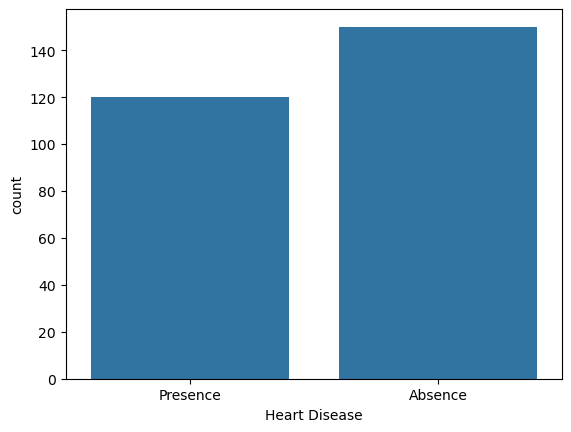

In [9]:
sns.countplot(x='Heart Disease', data=heart)
plt.show()

In [10]:
heart = pd.get_dummies(heart, drop_first=True)

In [11]:
X = heart.drop('Heart Disease_Presence', axis=1)
y = heart['Heart Disease_Presence']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)

SVC()

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[44  5]
 [ 9 23]]
              precision    recall  f1-score   support

       False       0.83      0.90      0.86        49
        True       0.82      0.72      0.77        32

    accuracy                           0.83        81
   macro avg       0.83      0.81      0.81        81
weighted avg       0.83      0.83      0.82        81



In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
'C':[0.1,1,10,100,1000],
'gamma':[1,0.1,0.01,0.001,0.0001],
'kernel':['rbf']
}

grid = GridSearchCV(SVC(), param_grid, refit=True)
grid.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']})

In [18]:
grid_predictions = grid.predict(X_test)

print(confusion_matrix(y_test, grid_predictions))
print(classification_report(y_test, grid_predictions))

[[44  5]
 [10 22]]
              precision    recall  f1-score   support

       False       0.81      0.90      0.85        49
        True       0.81      0.69      0.75        32

    accuracy                           0.81        81
   macro avg       0.81      0.79      0.80        81
weighted avg       0.81      0.81      0.81        81

